In [ ]:
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

import pandas as pd
#import matplotlib.pyplot as plt

from preprocessing import Preprocessor
#from model_builder import ModelBuilder
from plotting import Plotter

In [ ]:
#These seem to generalize well to other benchmarks as well
good_features = ['delta_io_bytes', 'delta_cycles', 'delta_cpu_ns', 'delta_branch_instructions', 'syscall_class_signal']# R² 98% and 3,15% for the workflow data which is crazy

target = "interval_energy"

DATA_PATH  = "data/process_interval_data_wf.parquet"
data = pd.read_parquet(DATA_PATH)
print("Loading data...")


Loading data...


In [3]:
class ModelBuilder():

    def __init__(self, X, y, times, alg_name="rf"):
        self.X = X
        self.y = y
        self.times = times
        self.alg_name = alg_name

    def _split(self):
        self.X_train, self.X_test, self.y_train, self.y_test, self.t_train, self.t_test = train_test_split(self.X, self.y, self.times, test_size=0.2, shuffle=False)

    def _scale(self):
        self.scaler = StandardScaler()
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

    def _train(self):
        if self.alg_name.lower() =="rf":
            self.model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        elif self.alg_name.lower() == "ebm":
            self.model = ExplainableBoostingRegressor(feature_names=good_features, interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
        else:
            print("No algorithm stored")
        
        self.model.fit(self.X_train_scaled, self.y_train)
    
    def _test(self):
        self.y_pred = self.model.predict(self.X_test_scaled)
    
    def _evaluate(self):
        r2 = r2_score(self.y_test, self.y_pred)
        mae = mean_absolute_error(self.y_test, self.y_pred)
        mean_energy = self.y_test.mean()
        mae_pct = (mae / mean_energy) * 100
        
        #print(f"Random Forest: [{self.X_test_scaled.columns}]")
        
        if self.alg_name.lower() =="rf":
            print(f" Random Forest")
        elif self.alg_name.lower() == "ebm":
            print(f" Explainable Boosting Machine ")
        else:
            print("No algorithm stored")

        print(f"  R² Score:  {r2:.4f}")
        print(f"  MAE:       {mae:.2f} Wh ({mae_pct:.2f}% of mean)")
        print("-" * 34)

    def _save_model(self,path, filename):
        filepath = os.path.join(path, filename)
        bundle = {
            "scaler": self.scaler,
            "model": self.model
        }        
        joblib.dump(bundle, filepath)
        print(f"Model and scaler successfully saved to: {filepath}")
    
    def run_model(self,):
        self._split()
        self._scale()
        self._train()
        self._test()
        self._evaluate()
        return self.y_pred, self.y_test, self.t_test
        
    
    def run_and_save_model(self, path="./"):
        if self.alg_name.lower() =="rf":
            model_name="random_forest.joblib"
        elif self.alg_name.lower() == "ebm":
            model_name="ebm.joblib"
        else:
            print("No algorithm stored")
        self._split()
        self._scale()
        self._train()
        self._test()
        self._evaluate()
        self._save_model(path, model_name)
        return self.X_test, self.y_pred, self.y_test, self.t_test

    

In [4]:
#Preprocessing
alg_name = "ebm"

preprocessor = Preprocessor(data, good_features)
X, y, times = preprocessor.preprocess()

builder = ModelBuilder(X, y, times, alg_name)

In [5]:
#Training data
X_test, y_pred, y_test, t_test = builder.run_and_save_model()


 Explainable Boosting Machine 
  R² Score:  0.9568
  MAE:       68.32 Wh (8.40% of mean)
----------------------------------
Model and scaler successfully saved to: ./ebm.joblib


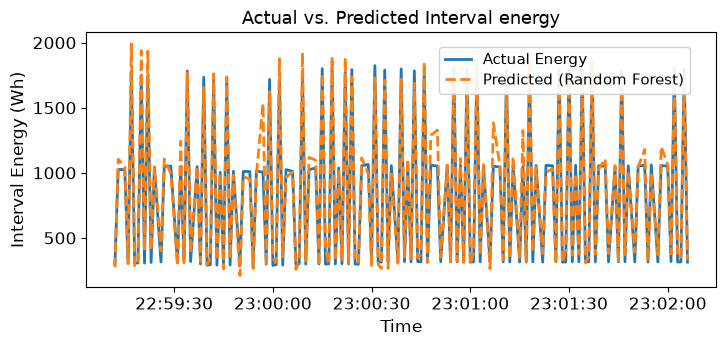

In [6]:
#Plotting
plotter = Plotter(y_pred,y_test, t_test, window_start =50, window_end=200)
plotter.plot_and_save()

In [7]:
model = joblib.load("ebm.joblib")
show(model['model'].explain_global())

<!-- http://127.0.0.1:7001/126174555649136/ -->

In [8]:
model['model']

,feature_names,"['delta_io_bytes', 'delta_cycles', ...]"
,interactions,2
,max_rounds,2000
,n_jobs,-1
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0


In [9]:
show(model['model'].explain_local(X_test[:5], y_test[:5]), 0)

<!-- http://127.0.0.1:7001/126174532920304/ -->